In [1]:
import os
import time
import importlib
import nest_asyncio
import featureExtractor as ext

# 주피터 노트북에서 이벤트 루프 재진입을 가능하게 함
nest_asyncio.apply()

importlib.reload(ext)

dataset = "FSD50K.dev_audio"
# 폴더 선택 다이얼로그 표시
selected_directory = f"./dataset/{dataset}"
features_pkl_path = f"./dataset/{dataset}_features.pkl"

if not selected_directory:
    print("Folder selection cancelled.")
else:
    # 현재 시간 가져오기
    current_time = time.strftime("%Y%m%d-%H%M%S")

    # 선택한 폴더명 추출
    folder_name = os.path.basename(os.path.normpath(selected_directory))
    file_name = f"{folder_name}"
    print(f"Processing folder: {selected_directory}")
    print(f"Generated file name: {file_name}")

    # 오디오 파일 읽어서 buffers 생성
    buffers = ext.readfile(selected_directory, file_name, detect_onset=True)

Processing folder: ./dataset/FSD50K.dev_audio
Generated file name: FSD50K.dev_audio
Loaded 40966 buffers from dataset/FSD50K.dev_audio.pkl.
readfile 처리 시간: 0.10초


In [2]:
import pickle

try:
    with open(features_pkl_path, 'rb') as f:
        features = pickle.load(f)
except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {features_pkl_path}")
    exit()

print(f"총 오디오 유닛 개수: {len(features)}\n")

if features and isinstance(features, list) and isinstance(features[0], dict):
    first_feature = features[0]
    print("첫번째 오디오 유닛의 메타데이터 구조:")
    for key, value in first_feature.items():
        print(f"  {key}: {value}")
else:
    print("불러온 데이터의 구조가 예상과 다릅니다.")

총 오디오 유닛 개수: 40966

첫번째 오디오 유닛의 메타데이터 구조:
  filename: 47608_best.wav
  mfccs_mean: [[-0.13919042  0.64240766  1.5619485 ]]
  spectral_centroid_mean: [[4013.2812 4119.616  4001.8652 3915.3196 3825.9807 3803.57   3636.4607
  3498.1882 3410.8357]]
  chroma_mean: [0.01690478 0.00955654 0.00354515 0.02342764 0.00568815 0.01101976
 0.05716948 0.01067797 0.12474751 0.29072607 0.25478843 0.19174843]
  excessive_onsets: False
  original_onset_count: 0
  onsets_per_second: 0
  audio_duration: 0.032


Spectral Centroid (Graph)

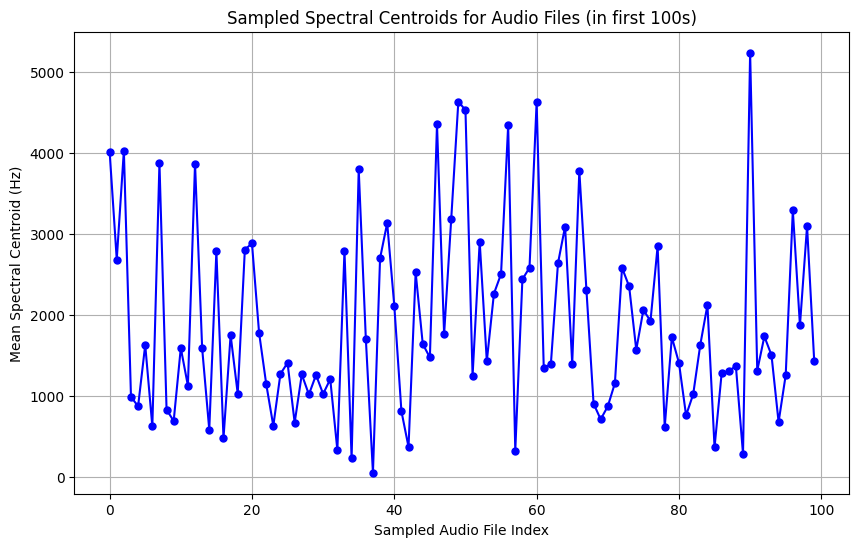

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# Extract the spectral centroid values from the features list
centroids_list = []
for feature_data in features_list:
    spectral_centroid_mean = feature_data.get('spectral_centroid_mean')
    if spectral_centroid_mean is not None:
        centroids_list.append(spectral_centroid_mean)

# Check if there are any valid centroids to plot
if not centroids_list:
    print("No valid audio files found or processed.")
else:
    # Convert the list of spectral centroids to a NumPy array
    centroids_array = np.array(centroids_list).reshape(-1, 1)

    # Optional: Reduce the number of data points by sampling
    sample_size = min(100, len(centroids_array))  # Limit to 100 samples
    indices = np.linspace(0, len(centroids_array) - 1, sample_size).astype(int)
    sampled_centroids = centroids_array[indices]

    # Plotting the sampled spectral centroids
    plt.figure(figsize=(10, 6))
    plt.plot(sampled_centroids, marker='o', linestyle='-', color='b', markersize=5)
    plt.title('Sampled Spectral Centroids for Audio Files (in first 100s)')
    plt.xlabel('Sampled Audio File Index')
    plt.ylabel('Mean Spectral Centroid (Hz)')
    plt.grid(True)
    plt.show()


In [4]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Define the path to the directory containing the audio files
directory_path = './Emo-soundscapes'

# Define the pickle file paths
buffers_pkl_path = 'buffers.pkl'
chroma_pkl_path = 'chroma.pkl'

# Check if the pickle files exist
if os.path.exists(buffers_pkl_path) and os.path.exists(chroma_pkl_path):
    # Load buffers and chroma features from pickle files
    with open(buffers_pkl_path, 'rb') as f:
        buffers = pickle.load(f)
    with open(chroma_pkl_path, 'rb') as f:
        chroma_list = pickle.load(f)
    print("Loaded buffers and chroma features from pickle files.")
else:
    # Initialize an empty list to store the buffers and their chroma features
    buffers = []
    chroma_list = []

    # Walk through the directory, including all subdirectories
    for root, _, files in os.walk(directory_path):
        for filename in files:
            if filename.endswith(".wav") or filename.endswith(".mp3"):
                # Construct the full file path
                file_path = os.path.join(root, filename)
                try:
                    # Load the audio file
                    audio_data, sample_rate = librosa.load(file_path, sr=None)
                    
                    # Compute the chroma features
                    chroma = librosa.feature.chroma_stft(y=audio_data, sr=sample_rate)
                    
                    # Append the buffer and chroma features to the lists
                    buffers.append((audio_data, sample_rate))
                    chroma_list.append(chroma)
                    
                    print(f"Processed file: {file_path}")
                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")

    # Save buffers to a file using pickle
    with open(buffers_pkl_path, 'wb') as f:
        pickle.dump(buffers, f)
    with open(chroma_pkl_path, 'wb') as f:
        pickle.dump(chroma_list, f)

    print("Processed audio files and saved buffers and chroma features to pickle files.")

# Check if chroma_list is empty
if not chroma_list:
    print("No valid audio files found or processed.")
else:
    # Visualizing the chroma features for the first audio file
    chroma_example = chroma_list[0]  # Use the first audio file for visualization

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(chroma_example, y_axis='chroma', x_axis='time')
    plt.colorbar()
    plt.title('Chroma Features')
    plt.xlabel('Time')
    plt.ylabel('Chroma')
    plt.show()


Loaded buffers and chroma features from pickle files.
No valid audio files found or processed.


In [5]:
# 첫 단계: 전체 데이터 구조 확인
print(f"특성 리스트 길이: {len(features_list)}")

# 두 번째 단계: 데이터 검증 정보 수집
valid_count = 0
dimension_issues = 0
missing_keys = 0
shape_histogram = {}

# 처음 몇 개 항목 검사
for idx, feature_data in enumerate(features_list[:20]):  # 처음 20개만 확인
    for key in desc_keys:
        data = feature_data.get(key)
        if data is None:
            print(f"인덱스 {idx}에서 키 {key} 누락")
            missing_keys += 1
            continue
            
        arr = np.array(data)
        shape_str = str(arr.shape)
        shape_histogram[shape_str] = shape_histogram.get(shape_str, 0) + 1
        
        if arr.ndim > 2:
            print(f"인덱스 {idx}의 키 {key}: 지원되지 않는 차원 {arr.ndim} (형태: {arr.shape})")
            dimension_issues += 1

# 결과 출력
print(f"\n특성 형태 분포:")
for shape, count in shape_histogram.items():
    print(f"  {shape}: {count}개")
print(f"\n누락된 키: {missing_keys}")
print(f"차원 문제: {dimension_issues}")

특성 리스트 길이: 40966


NameError: name 'desc_keys' is not defined

t-SNE'd MFCC Data

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm  # tqdm 임포트
from sklearn.decomposition import PCA  # 추가: sklearn.decomposition에서 PCA 임포트
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# 리스트에 3가지 오디오 설명자를 결합한 값을 저장
descriptors_list = []

# 3가지 설명자 키 (featureExtractor.py에 정의된 키 사용)
desc_keys = ['mfccs_mean', 'spectral_centroid_mean', 'chroma_mean']

# Extract and combine descriptors for each audio unit
for idx, feature_data in enumerate(tqdm(features_list, desc='Extracting descriptors')):
    combined = []
    valid = True
    for key in desc_keys:
        data = feature_data.get(key)
        if data is None:
            valid = False
            break
        arr = np.array(data)
        # 만약 스칼라(0차원)라면 1차원 배열로 변환
        if arr.ndim == 0:
            arr = np.array([arr])
        # 2D 데이터인 경우 시간축 평균을 취함
        elif arr.ndim == 2:
            arr = np.mean(arr, axis=1)
        elif arr.ndim != 1:
            valid = False
            break
        combined.append(arr)
    if valid and len(combined) == len(desc_keys):
        # Concatenate the descriptors along axis 0
        combined_descriptor = np.concatenate(combined)
        descriptors_list.append(combined_descriptor)
    else:
        print(f"Skipping feature_data index {idx}: missing or invalid descriptors.")


# 모든 feature vector의 길이가 동일한지 확인 후 필터링
valid_descriptors = []
valid_indices = []  # 원본 인덱스 저장 리스트
target_len = None
for i, vec in enumerate(descriptors_list):
    vec = np.array(vec)
    if vec.size == 0:
        continue
    if target_len is None:
        target_len = vec.shape[0]
    if vec.shape[0] == target_len:
        valid_descriptors.append(vec)
        valid_indices.append(i)

descriptors_array = np.vstack(valid_descriptors)
# Perform t-SNE to reduce dimensionality to 3D (진행 상황은 TSNE 객체의 verbose 옵션을 통해 확인 가능)
tsne = TSNE(n_components=3, random_state=0, verbose=1)
descriptors_3d = tsne.fit_transform(descriptors_array)

# Normalize the 3D coordinates to fit in the range 0 to 1
min_vals = descriptors_3d.min(axis=0)
max_vals = descriptors_3d.max(axis=0)
descriptors_3d_normalized = (descriptors_3d - min_vals) / (max_vals - min_vals)

# ------------------------------------------------------------------
# [추가] t-SNE 임베딩에 대한 클러스터링 및 거리 분포 점수 계산
k = 10
kmeans_tsne = KMeans(n_clusters=k, random_state=0)
labels_tsne = kmeans_tsne.fit_predict(descriptors_3d_normalized)
sil_score_tsne = silhouette_score(descriptors_3d_normalized, labels_tsne)
print("Silhouette Score on t-SNE embedding:", sil_score_tsne)

tsne_distances = pdist(descriptors_3d_normalized)
mean_tsne_distance = np.mean(tsne_distances)
std_tsne_distance = np.std(tsne_distances)
print(f"t-SNE Euclidean distance: {mean_tsne_distance:.2f} (±{std_tsne_distance:.2f})")

Extracting descriptors: 100%|██████████| 40966/40966 [00:00<00:00, 85110.02it/s]


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 40966 samples in 0.011s...
[t-SNE] Computed neighbors for 40966 samples in 0.373s...
[t-SNE] Computed conditional probabilities for sample 1000 / 40966
[t-SNE] Computed conditional probabilities for sample 2000 / 40966
[t-SNE] Computed conditional probabilities for sample 3000 / 40966
[t-SNE] Computed conditional probabilities for sample 4000 / 40966
[t-SNE] Computed conditional probabilities for sample 5000 / 40966
[t-SNE] Computed conditional probabilities for sample 6000 / 40966
[t-SNE] Computed conditional probabilities for sample 7000 / 40966
[t-SNE] Computed conditional probabilities for sample 8000 / 40966
[t-SNE] Computed conditional probabilities for sample 9000 / 40966
[t-SNE] Computed conditional probabilities for sample 10000 / 40966
[t-SNE] Computed conditional probabilities for sample 11000 / 40966
[t-SNE] Computed conditional probabilities for sample 12000 / 40966
[t-SNE] Computed conditional probabilities for sam

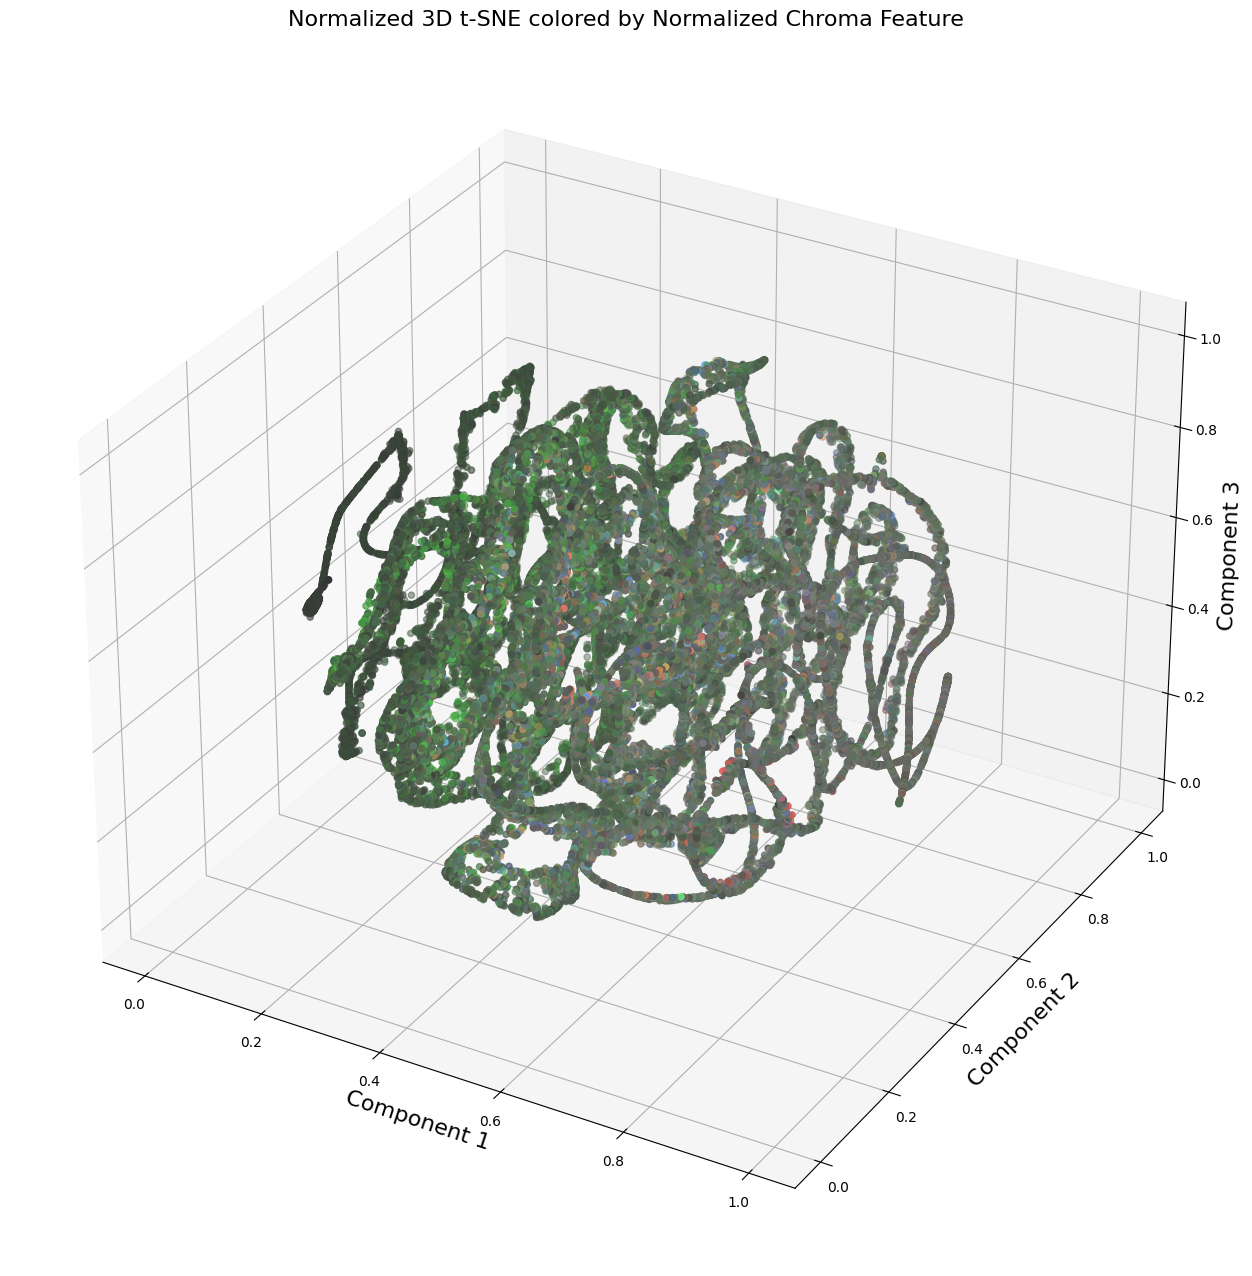

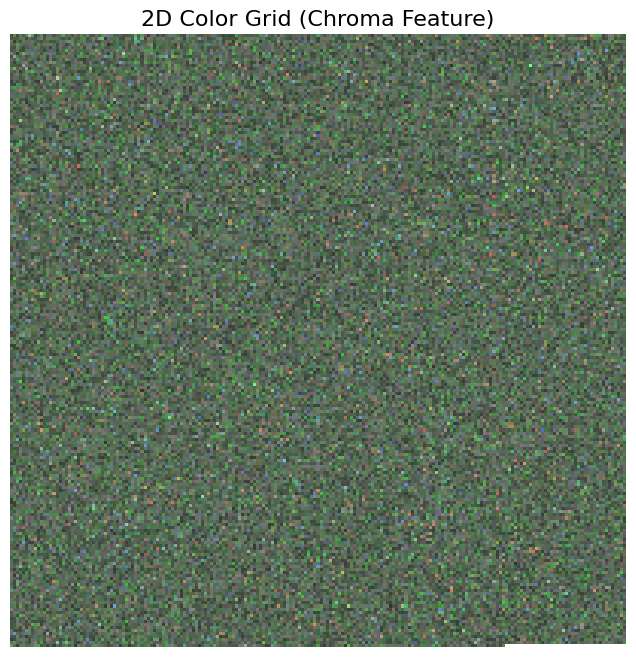

ValueError: 'c' argument has 1474776 elements, which is inconsistent with 'x' and 'y' with size 40966.

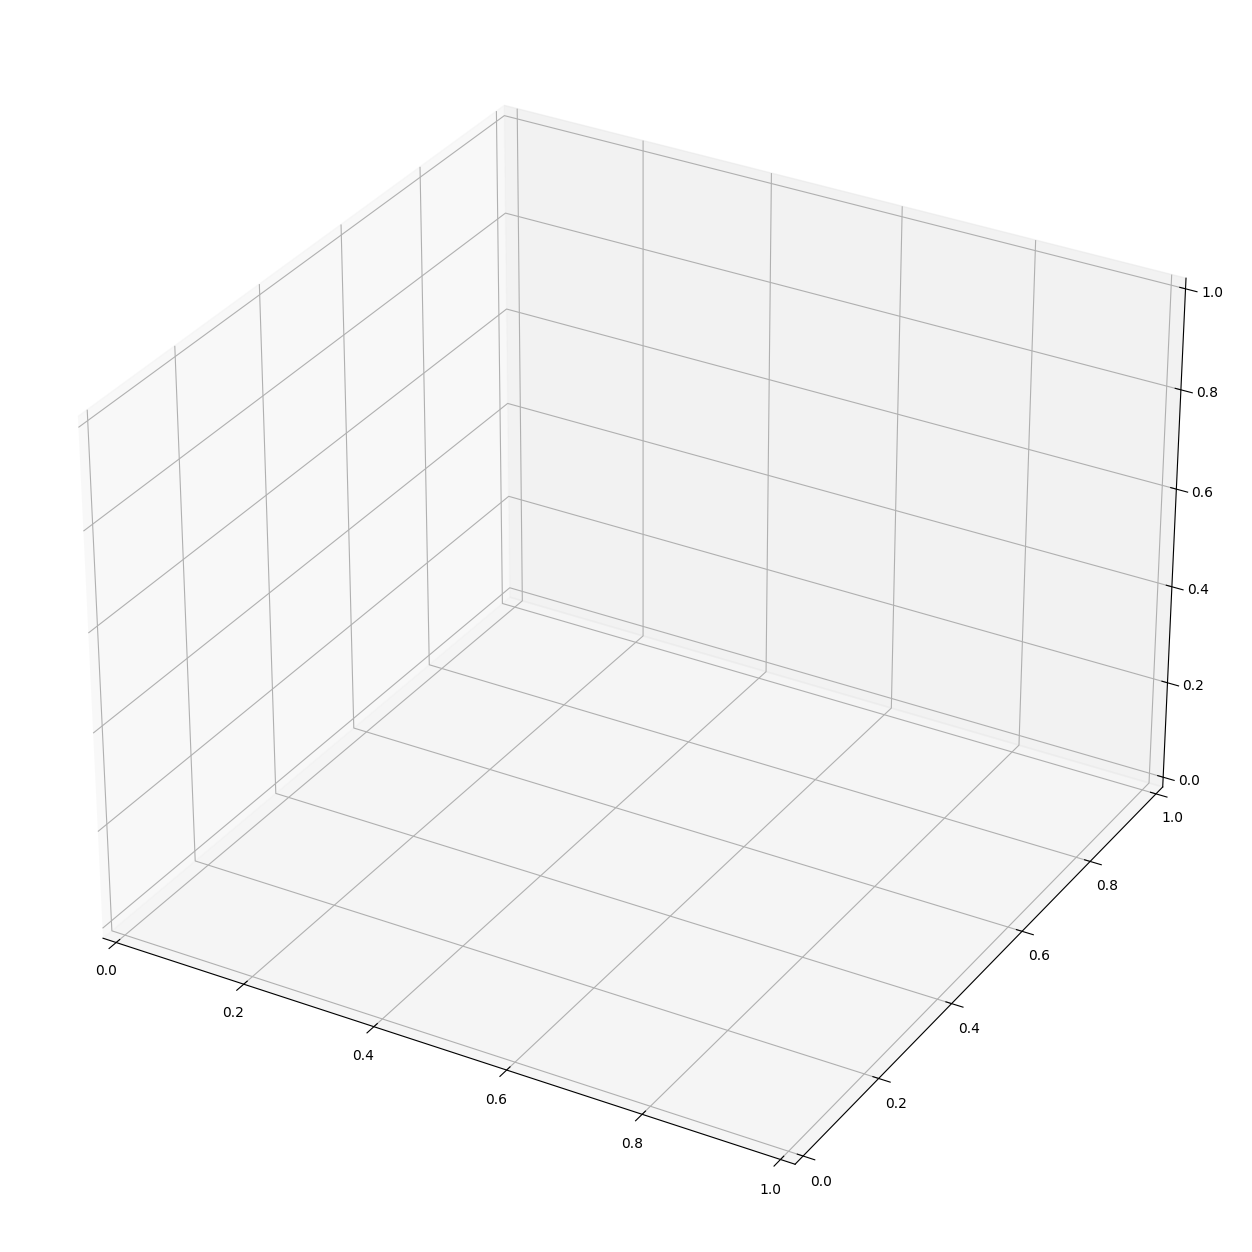

In [8]:
# Define a variable for font size
fontsize = 16


# ------------------------------------------------------------------
# 1. 색상 매핑: 크로마 피쳐 (chroma_mean)의 앞 3개 값을 RGB로 사용하되 정규화 적용
chroma_all_for_norm = []
for i in valid_indices:
    feature_data = features_list[i]
    chroma = np.array(feature_data.get('chroma_mean', []))
    if chroma.size < 3:
        chroma = np.pad(chroma, (0, 3 - chroma.size), mode='constant', constant_values=0)
    elif chroma.size > 3:
        chroma = chroma[:3]
    chroma_all_for_norm.append(chroma)

chroma_all_for_norm = np.array(chroma_all_for_norm)

# 크로마 값 전체를 기준으로 정규화
chroma_min = np.min(chroma_all_for_norm, axis=0)
chroma_max = np.max(chroma_all_for_norm, axis=0)
chroma_range = chroma_max - chroma_min
# 0으로 나누는 것을 방지
chroma_range = np.where(chroma_range < 1e-10, 1.0, chroma_range)

# 각 크로마 값을 정규화하여 0~1 범위로 변환
chroma_colors = []
for i in range(len(valid_indices)):
    normalized_chroma = (chroma_all_for_norm[i] - chroma_min) / chroma_range
    # 밝기를 높이기 위해 감마 보정 적용 (0.5는 더 밝게 만듦)
    normalized_chroma = np.power(normalized_chroma, 0.5)
    # 색상 대비를 높이기 위해 값 조정 (최소값을 0.2로 설정)
    normalized_chroma = 0.2 + 0.8 * normalized_chroma
    # 최종 0~1 범위 보장
    normalized_chroma = np.clip(normalized_chroma, 0, 1)
    chroma_colors.append(normalized_chroma)

chroma_colors = np.array(chroma_colors)

# 3D scatter plot using chroma-based colors
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    descriptors_3d_normalized[:, 0],
    descriptors_3d_normalized[:, 1],
    descriptors_3d_normalized[:, 2],
    c=chroma_colors,
    marker='o'
)
ax.set_title('Normalized 3D t-SNE colored by Normalized Chroma Feature', fontsize=fontsize)
ax.set_xlabel('Component 1', fontsize=fontsize)
ax.set_ylabel('Component 2', fontsize=fontsize)
ax.set_zlabel('Component 3', fontsize=fontsize)
plt.savefig('chroma_3d_scatter.png')
plt.show()

# 2D color grid for chroma-based colors
grid_size = int(np.ceil(np.sqrt(len(chroma_colors))))
padded_chroma = np.pad(
    chroma_colors,
    ((0, grid_size**2 - len(chroma_colors)), (0, 0)),
    mode='constant',
    constant_values=1.0
)
chroma_grid = padded_chroma.reshape((grid_size, grid_size, 3))
plt.figure(figsize=(8, 8))
plt.imshow(chroma_grid)
plt.title('2D Color Grid (Chroma Feature)', fontsize=fontsize)
plt.axis('off')
plt.savefig('chroma_2d_grid.png')
plt.show()

# ------------------------------------------------------------------
# 2. 색상 매핑: 스펙트럴 중심값 (spectral_centroid_mean)을 이용한 매핑
spectral_values = []
for i in valid_indices:
    feature_data = features_list[i]
    spec = feature_data.get('spectral_centroid_mean', 0.0)
    spectral_values.append(spec)
spectral_values = np.array(spectral_values)
# 스펙트럴 중심값 normalize (0~1)
spec_min, spec_max = spectral_values.min(), spectral_values.max()
spectral_norm = (spectral_values - spec_min) / (spec_max - spec_min)
# viridis colormap 적용
cmap = plt.cm.viridis
spectral_colors = cmap(spectral_norm)[:, :3]

# 3D scatter plot using spectral centroid based colors
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    descriptors_3d_normalized[:, 0],
    descriptors_3d_normalized[:, 1],
    descriptors_3d_normalized[:, 2],
    c=spectral_colors,
    marker='o'
)
ax.set_title('Normalized 3D t-SNE colored by Spectral Centroid', fontsize=fontsize)
ax.set_xlabel('Component 1', fontsize=fontsize)
ax.set_ylabel('Component 2', fontsize=fontsize)
ax.set_zlabel('Component 3', fontsize=fontsize)
plt.savefig('spectral_3d_scatter.png')
plt.show()

# 3. 색상 매핑 (PCA 적용한 크로마 벡터 + 정규화 개선)
chroma_all = []
for i in valid_indices:
    feature_data = features_list[i]
    chroma = np.array(feature_data.get('chroma_mean', []))
    if chroma.size < 12:
        chroma = np.pad(chroma, (0, 12 - chroma.size), mode='constant', constant_values=0)
    elif chroma.size > 12:
        chroma = chroma[:12]
    chroma_all.append(chroma)
chroma_all = np.array(chroma_all)

# 각 차원별로 정규화하여 극단적인 값 차이 해소
chroma_min = np.min(chroma_all, axis=0)
chroma_max = np.max(chroma_all, axis=0)
chroma_range = chroma_max - chroma_min
# 0으로 나누는 것을 방지
chroma_range = np.where(chroma_range < 1e-10, 1.0, chroma_range)
chroma_normalized = (chroma_all - chroma_min) / chroma_range

# 정규화된 데이터로 PCA 수행
pca = PCA(n_components=3)
chroma_pca = pca.fit_transform(chroma_normalized)

# PCA 결과 정규화 및 색상 향상
min_vals_pca = chroma_pca.min(axis=0)
max_vals_pca = chroma_pca.max(axis=0)
chroma_pca_normalized = (chroma_pca - min_vals_pca) / (max_vals_pca - min_vals_pca)

# 색상 대비와 밝기 향상 (감마 보정 및 최소값 설정)
chroma_pca_enhanced = np.power(chroma_pca_normalized, 0.5)  # 감마 보정
chroma_pca_enhanced = 0.2 + 0.8 * chroma_pca_enhanced  # 최소값 0.2 설정
chroma_pca_enhanced = np.clip(chroma_pca_enhanced, 0, 1)  # 0~1 범위 보장

# 3D scatter plot: t-SNE 결과에 향상된 PCA 색상 적용
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# 점 크기 계산 부분은 기존 코드와 동일
xy_distance = np.sqrt(
    np.tan(descriptors_3d_normalized[:, 0])**2 + 
    np.tan(descriptors_3d_normalized[:, 1])**2
)
distance_norm = np.clip(xy_distance, 0.1, np.max(xy_distance))
point_sizes = (distance_norm / np.min(distance_norm)) / 30
point_sizes = np.clip(point_sizes, 5, 50)

ax.scatter(
    descriptors_3d_normalized[:, 0],
    descriptors_3d_normalized[:, 1],
    descriptors_3d_normalized[:, 2],
    c=chroma_pca_enhanced,  # 향상된 색상 적용
    marker='o',
    s=point_sizes
)

ax.set_title('Normalized 3D t-SNE colored by Enhanced PCA-Chroma', fontsize=fontsize)
ax.set_xlabel('Component 1', fontsize=fontsize)
ax.set_ylabel('Component 2', fontsize=fontsize)
ax.set_zlabel('Component 3', fontsize=fontsize)
plt.savefig('pca_chroma_3d_scatter.png')
plt.show()

# # 2D 색상 그리드 (PCA 색상)
# grid_size = int(np.ceil(np.sqrt(len(chroma_pca_normalized))))
# padded_pca = np.pad(
#     chroma_pca_normalized,
#     ((0, grid_size**2 - len(chroma_pca_normalized)), (0, 0)),
#     mode='constant',
#     constant_values=1.0
# )
# pca_grid = padded_pca.reshape((grid_size, grid_size, 3))
# plt.figure(figsize=(8, 8))
# plt.imshow(pca_grid)
# plt.title('2D Color Grid (PCA-applied Chroma Feature)')
# plt.axis('off')
# plt.savefig('pca_chroma_2d_grid.png')
# plt.show()

✅ Completed batch 15/16
🔄 Overall progress: 94.0%


Batch 16/16:   0%|          | 0/10 [00:00<?, ?it/s]

✨ Displaying plot...


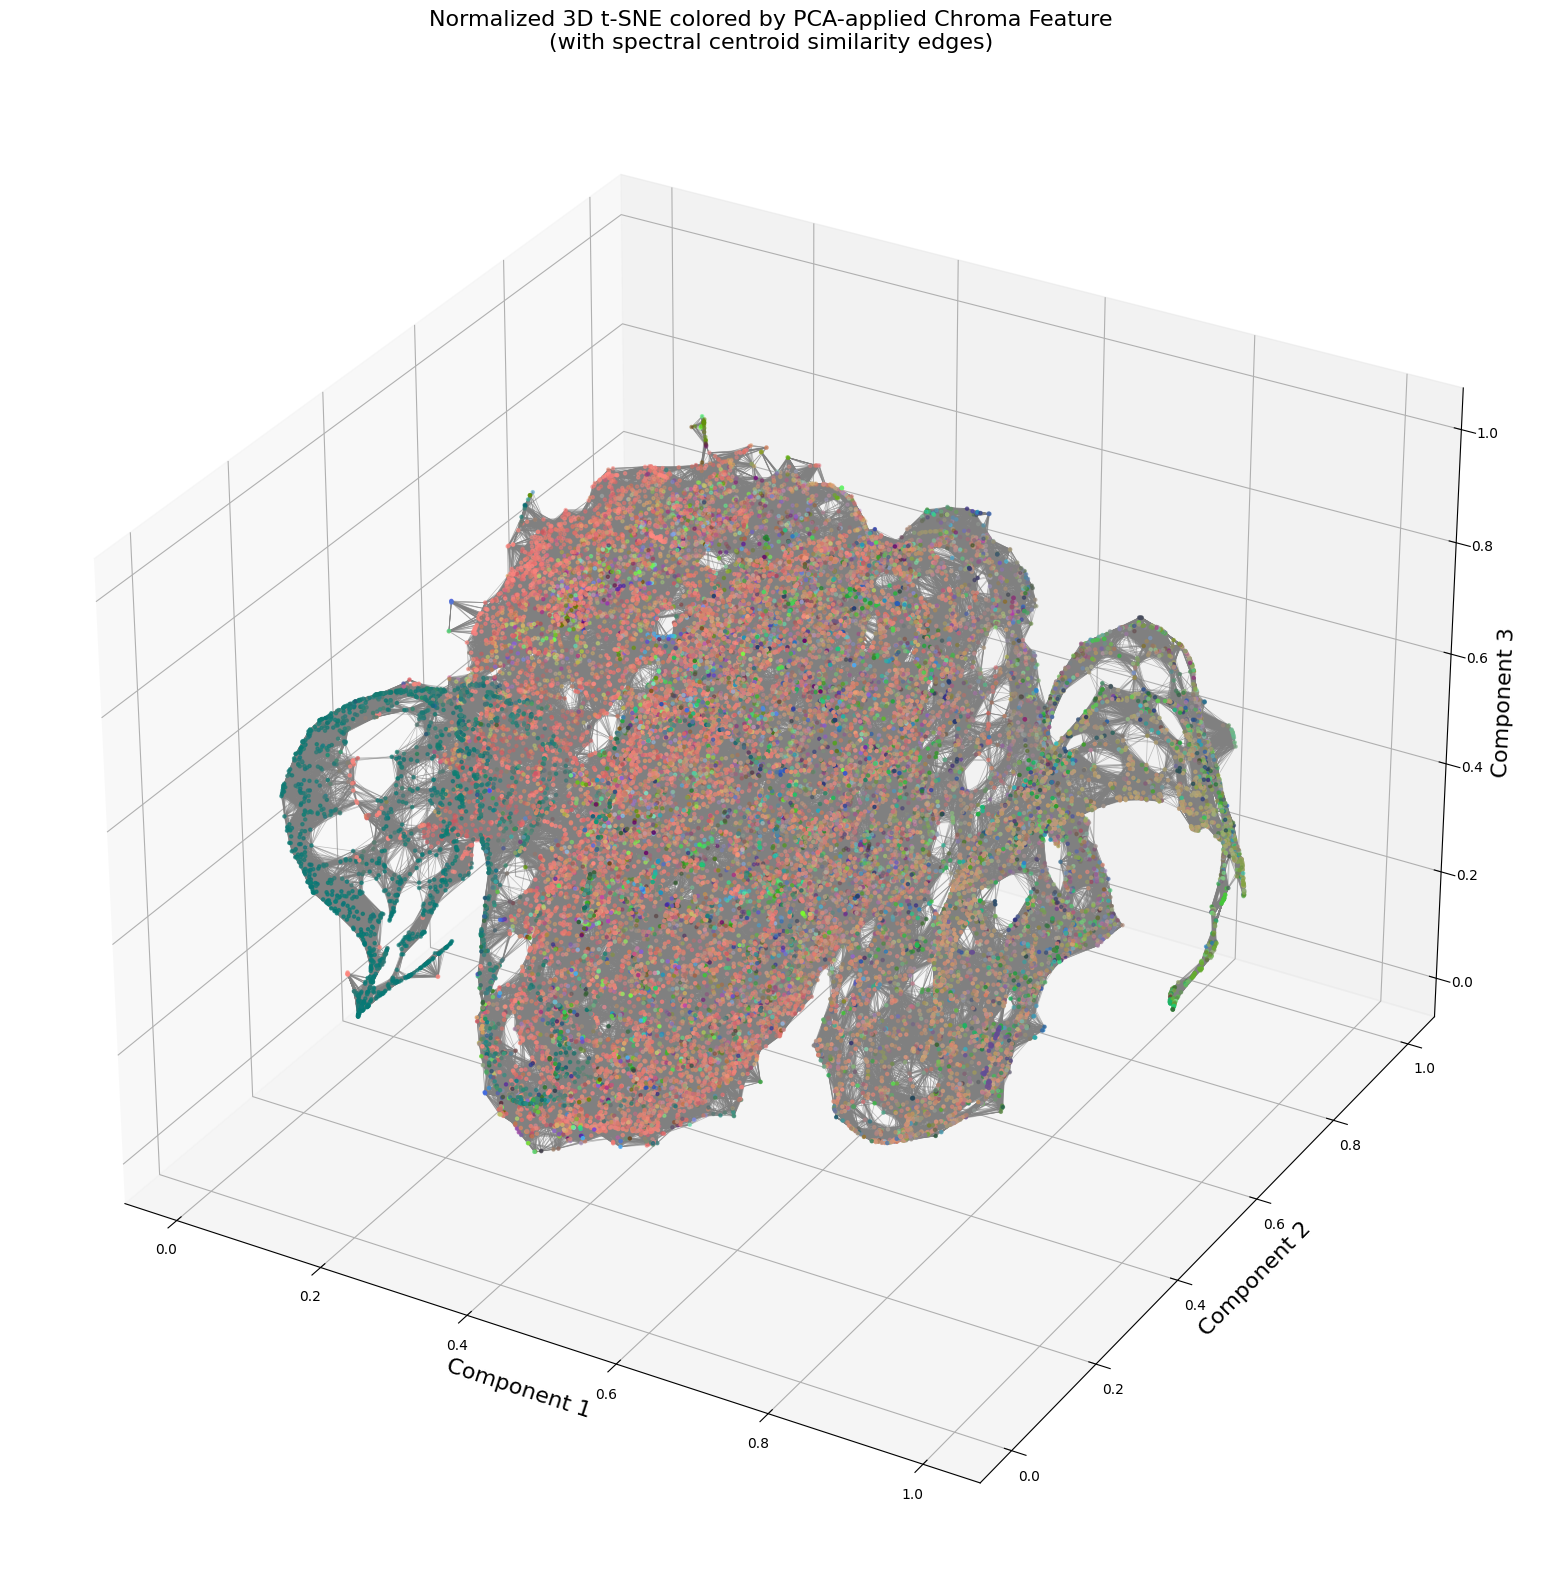

✅ Visualization complete!


In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from tqdm.notebook import tqdm  # 주피터 노트북에 특화된 tqdm 사용
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
import warnings
from IPython.display import clear_output  # 출력 정리를 위한 임포트

# joblib 출력 경고 숨기기
warnings.filterwarnings("ignore", category=UserWarning, module='joblib')

# 계산 결과를 저장할 PKL 파일 경로 정의
processed_data_path = './processed_tsne_data.pkl'

# 병렬 처리에 사용할 코어 수 설정
n_jobs = None

# 파일이 존재하는지 확인하고 있으면 불러오기, 없으면 계산 실행
if os.path.exists(processed_data_path):
    print(f"Loading pre-processed data from {processed_data_path}")
    with open(processed_data_path, 'rb') as f:
        saved_data = pickle.load(f)
    
    # 저장된 데이터 불러오기
    descriptors_3d_normalized = saved_data['descriptors_3d_normalized']
    chroma_pca_normalized = saved_data['chroma_pca_normalized']
    spectral_norm = saved_data['spectral_norm']
    tsne_dists = saved_data['tsne_dists']
    spec_diffs = saved_data['spec_diffs']
    threshold_tsne = saved_data['threshold_tsne']
    threshold_spec = saved_data['threshold_spec']
    pairs = saved_data['pairs']
    
    print("✅ Data loaded successfully!")
else:
    print("🔄 Pre-processed data not found. Calculating...")
    
    # --- 병렬 계산 코드 시작 ---
    # 특성 추출 함수 정의 (개별 작업 단위)
    def extract_spectral(idx):
        feature_data = features_list[idx]
        spec = feature_data.get('spectral_centroid_mean', 0.0)
        return spec
    
    def extract_chroma(idx):
        feature_data = features_list[idx]
        chroma = np.array(feature_data.get('chroma_mean', []))
        if chroma.size < 12:
            chroma = np.pad(chroma, (0, 12 - chroma.size), mode='constant', constant_values=0)
        elif chroma.size > 12:
            chroma = chroma[:12]
        return chroma
    
    # 병렬 처리로 스펙트럴 중심값 추출 - verbose=0으로 설정해 출력 숨김
    print("🔄 Extracting spectral centroid values in parallel...")
    pbar_spectral = tqdm(total=len(valid_indices), desc="Extracting spectral values")
    
    def update_pbar(*args):
        pbar_spectral.update()
    
    spectral_values = Parallel(n_jobs=n_jobs, verbose=0, batch_size=100)(
        delayed(extract_spectral)(i) for i in valid_indices
    )
    spectral_values = np.array(spectral_values)
    pbar_spectral.close()
    
    # 스펙트럴 센트로이드 정규화
    print("🔄 Normalizing spectral centroid values...")
    spec_min, spec_max = spectral_values.min(), spectral_values.max()
    spectral_norm = (spectral_values - spec_min) / (spec_max - spec_min)
    
    # 병렬 처리로 크로마 데이터 추출
    print("🔄 Extracting chroma values in parallel...")
    pbar_chroma = tqdm(total=len(valid_indices), desc="Extracting chroma values")
    
    chroma_all = []
    # 배치 처리로 진행 표시 개선
    batch_size = 100
    for i in range(0, len(valid_indices), batch_size):
        batch_indices = valid_indices[i:i+batch_size]
        batch_results = Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(extract_chroma)(idx) for idx in batch_indices
        )
        chroma_all.extend(batch_results)
        pbar_chroma.update(len(batch_indices))
    
    chroma_all = np.array(chroma_all)
    pbar_chroma.close()
    
    # PCA 적용
    print("🔄 Applying PCA to chroma features...")
    pca = PCA(n_components=3)
    chroma_pca = pca.fit_transform(chroma_all)
    min_vals_pca = chroma_pca.min(axis=0)
    max_vals_pca = chroma_pca.max(axis=0)
    chroma_pca_normalized = (chroma_pca - min_vals_pca) / (max_vals_pca - min_vals_pca)
    
    # 선분 연결 조건
    threshold_tsne = 0.05
    threshold_spec = 0.1
    
    # 거리 계산은 이미 최적화된 벡터 연산이므로 순차 실행
    print("🔄 Computing pairwise distances...")
    with tqdm(total=2, desc="Distance calculations") as pbar:
        tsne_dists = squareform(pdist(descriptors_3d_normalized))
        pbar.update(1)
        spec_diffs = squareform(pdist(spectral_norm.reshape(-1, 1), metric='cityblock'))
        pbar.update(1)
    
    # 두 조건을 만족하는 인덱스 쌍 검색 (벡터 연산)
    print("🔄 Finding matching pairs...")
    pairs = np.where((tsne_dists < threshold_tsne) & (spec_diffs < threshold_spec))
    print(f"✅ Found {len(pairs[0])} matching pairs")
    
    # 계산된 데이터 저장
    save_data = {
        'descriptors_3d_normalized': descriptors_3d_normalized,
        'chroma_pca_normalized': chroma_pca_normalized,
        'spectral_norm': spectral_norm,
        'tsne_dists': tsne_dists,
        'spec_diffs': spec_diffs,
        'threshold_tsne': threshold_tsne,
        'threshold_spec': threshold_spec,
        'pairs': pairs
    }
    
    print(f"💾 Saving processed data to {processed_data_path}")
    with tqdm(total=1, desc="Saving data") as pbar:
        with open(processed_data_path, 'wb') as f:
            pickle.dump(save_data, f)
        pbar.update(1)
    print("✅ Data saved successfully!")
    # --- 병렬 계산 코드 종료 ---

# 시각화 코드 시작
print("🎨 Creating 3D scatter plot...")
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# 각 점의 xyz 좌표로부터 원점과의 거리 계산
print("📐 Calculating point sizes based on distances...")
with tqdm(total=3, desc="Point size calculations") as pbar:
    xyz_distance = np.sqrt(
        descriptors_3d_normalized[:, 0]**2 + 
        descriptors_3d_normalized[:, 1]**2 + 
        descriptors_3d_normalized[:, 2]**2
    )
    pbar.update(1)
    
    # 거리에 비례하게 점 크기 조정
    distance_norm = np.clip(xyz_distance, np.min(xyz_distance), np.max(xyz_distance))
    pbar.update(1)
    point_sizes = 1 / (distance_norm / np.min(distance_norm))
    point_sizes = np.clip(point_sizes, 5, 50)
    pbar.update(1)

# 점 그래프 그리기
print("🔵 Drawing scatter points...")
scatter = ax.scatter(
    descriptors_3d_normalized[:, 0],
    descriptors_3d_normalized[:, 1],
    descriptors_3d_normalized[:, 2],
    c=chroma_pca_normalized,
    marker='o',
    s=point_sizes
)

# 중복 처리를 위한 필터링
print("🔍 Filtering valid pairs...")
valid_pairs = []
for k in tqdm(range(len(pairs[0])), desc="Filtering pairs"):
    if pairs[0][k] < pairs[1][k]:  # 중복 제거
        valid_pairs.append((pairs[0][k], pairs[1][k]))
print(f"✅ Found {len(valid_pairs)} valid pairs after filtering")

# 선 그리기를 위한 함수 - 여러 쌍을 한 번에 처리
def draw_lines_batch(batch_pairs):
    lines = []
    for i, j in batch_pairs:
        xs = [descriptors_3d_normalized[i, 0], descriptors_3d_normalized[j, 0]]
        ys = [descriptors_3d_normalized[i, 1], descriptors_3d_normalized[j, 1]]
        zs = [descriptors_3d_normalized[i, 2], descriptors_3d_normalized[j, 2]]
        lines.append((xs, ys, zs))
    return lines

# 배치 처리 및 진행률 표시
print("📊 Drawing lines between similar points...")
batch_size = 50000
sub_batch_size = 5000  #한 번에 병렬 처리할 선분 쌍 수
total_batches = (len(valid_pairs) + batch_size - 1) // batch_size
print(f"📦 Processing in {total_batches} batches of {batch_size} pairs each")

overall_progress = tqdm(total=len(valid_pairs), desc="Overall line drawing progress")

for batch_idx in range(total_batches):
    start_idx = batch_idx * batch_size
    end_idx = min((batch_idx + 1) * batch_size, len(valid_pairs))
    current_batch_pairs = valid_pairs[start_idx:end_idx]
    
    # 각 서브 배치에서 여러 선분을 한 번에 처리 (계산 효율 향상)
    sub_batches = []
    for i in range(0, len(current_batch_pairs), sub_batch_size):
        sub_batch = current_batch_pairs[i:i+sub_batch_size]
        sub_batches.append(sub_batch)
    
    # 병렬로 서브 배치 처리 (각 작업이 더 많은 선분 처리)
    lines_by_batch = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(draw_lines_batch)(sub_batch) for sub_batch in sub_batches
    )
    
    # 선 그리기
    batch_progress = tqdm(total=len(lines_by_batch), desc=f"Batch {batch_idx+1}/{total_batches}")
    for lines in lines_by_batch:
        for xs, ys, zs in lines:
            ax.plot(xs, ys, zs, c='gray', alpha=0.5, linewidth=0.5)
        batch_progress.update(1)
        overall_progress.update(len(lines))  # 서브 배치에 있는 선의 수만큼 업데이트
    batch_progress.close()
    
    # 배치 처리 후 출력 정리
    if batch_idx < total_batches - 1:  # 마지막 배치가 아니면 출력 정리
        clear_output(wait=True)
        print(f"✅ Completed batch {batch_idx+1}/{total_batches}")
        print(f"🔄 Overall progress: {min(1.0, (batch_idx+1) * batch_size / len(valid_pairs)):.1%}")

overall_progress.close()

fontsize = 16
ax.set_title('Normalized 3D t-SNE colored by PCA-applied Chroma Feature\n(with spectral centroid similarity edges)', fontsize=fontsize)
ax.set_xlabel('Component 1', fontsize=fontsize)
ax.set_ylabel('Component 2', fontsize=fontsize)
ax.set_zlabel('Component 3', fontsize=fontsize)

print("✨ Displaying plot...")
plt.tight_layout()
plt.show()
print("✅ Visualization complete!")

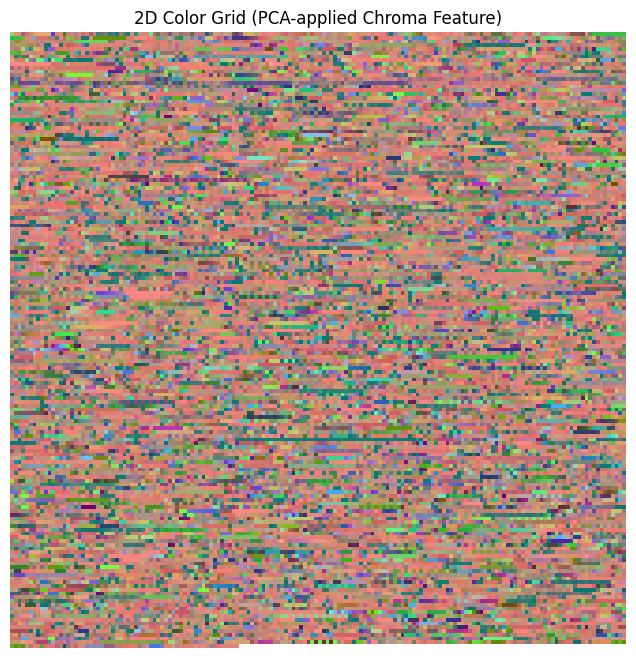

In [ ]:
# 2D 색상 그리드 (PCA 적용 크로마 색상)
grid_size = int(np.ceil(np.sqrt(len(chroma_pca_normalized))))
padded_pca = np.pad(
    chroma_pca_normalized,
    ((0, grid_size**2 - len(chroma_pca_normalized)), (0, 0)),
    mode='constant',
    constant_values=1.0
)
pca_grid = padded_pca.reshape((grid_size, grid_size, 3))
plt.figure(figsize=(8, 8))
plt.imshow(pca_grid)
plt.title('2D Color Grid (PCA-applied Chroma Feature)')
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import umap.umap_ as umap
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans  # KMeans 임포트 추가
from sklearn.metrics import silhouette_score  # 실루엣 스코어 임포트 추가
from tqdm import tqdm

# features_list 로드 (features_pkl_path 는 미리 정의했다고 가정)
try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# 복합 설명자 데이터셋 구축: 'mfccs_mean', 'spectral_centroid_mean', 'chroma_mean'
desc_keys = ['mfccs_mean', 'spectral_centroid_mean', 'chroma_mean']
descriptors_list = []
valid_indices = []  # 원본 features_list의 인덱스를 저장

for idx, feature_data in enumerate(tqdm(features_list, desc='Extracting composite descriptors')):
    combined = []
    valid = True
    for key in desc_keys:
        data = feature_data.get(key)
        if data is None:
            valid = False
            break
        arr = np.array(data)
        # 스칼라인 경우 1차원 배열로 변환
        if arr.ndim == 0:
            arr = np.array([arr])
        # 2차원인 경우 시간축 평균
        elif arr.ndim == 2:
            arr = np.mean(arr, axis=1)
        elif arr.ndim != 1:
            valid = False
            break
        combined.append(arr)
    if valid and len(combined) == len(desc_keys):
        composite_descriptor = np.concatenate(combined)
        descriptors_list.append(composite_descriptor)
        valid_indices.append(idx)
    else:
        print(f"Skipping feature_data index {idx}: missing or invalid descriptors.")

if not descriptors_list:
    print("No valid composite descriptor data found.")
else:
    # 모든 설명자 벡터의 길이가 동일한 경우만 선택
    valid_descriptors = []
    new_valid_indices = []
    target_len = None
    for i, vec in enumerate(descriptors_list):
        vec = np.array(vec)
        if vec.size == 0:
            continue
        if target_len is None:
            target_len = vec.shape[0]
        if vec.shape[0] == target_len:
            valid_descriptors.append(vec)
            new_valid_indices.append(valid_indices[i])
    valid_indices = np.array(new_valid_indices)
    descriptors_array = np.vstack(valid_descriptors)
    
    # --- 샘플링: 전체 설명자 중 일부(예: 2500개)를 무작위로 선택
    sample_count = 2500
    if len(descriptors_array) >= sample_count:
        sample_inds = np.random.choice(len(descriptors_array), sample_count, replace=False)
    else:
        sample_inds = np.arange(len(descriptors_array))
    descriptors_array_sample = descriptors_array[sample_inds]
    valid_indices_sample = valid_indices[sample_inds]
    
    # UMAP을 이용하여 샘플된 복합 설명자 데이터를 3차원으로 압축 
    umap_model = umap.UMAP(n_components=3, random_state=42, verbose=True, n_neighbors=15, min_dist=0.1, n_jobs=4)
    composite_umap_sample = umap_model.fit_transform(descriptors_array_sample)
    
    # UMAP 임베딩 결과 normalize (0~1)
    min_vals = composite_umap_sample.min(axis=0)
    max_vals = composite_umap_sample.max(axis=0)
    umap_normalized = (composite_umap_sample - min_vals) / (max_vals - min_vals)
    
    # UMAP 데이터에 K-means 클러스터링 적용
    k = 10
    kmeans_umap = KMeans(n_clusters=k, random_state=0)
    labels_umap = kmeans_umap.fit_predict(umap_normalized)  # 올바른 변수명 사용
    
    # UMAP 데이터의 실루엣 스코어 계산
    sil_score_umap = silhouette_score(umap_normalized, labels_umap)  # 올바른 변수명 사용
    
    # 실루엣 스코어 출력
    print(f"UMAP 데이터의 실루엣 스코어 (k={k}): {sil_score_umap:.4f}")
    
    # 각 유닛의 크로마 벡터(12차원)를 valid_indices_sample를 통해 수집하고, 12차원 미만이면 패딩, 초과면 자르기
    chroma_all = []
    for i in valid_indices_sample:
        feature_data = features_list[i]
        chroma = np.array(feature_data.get('chroma_mean', []))
        if chroma.size < 12:
            chroma = np.pad(chroma, (0, 12 - chroma.size), mode='constant', constant_values=0)
        elif chroma.size > 12:
            chroma = chroma[:12]
        chroma_all.append(chroma)
    chroma_all = np.array(chroma_all)
    
    # PCA를 적용하여 12차원 크로마 벡터를 3차원 색상으로 축소 및 normalize
    pca = PCA(n_components=3)
    chroma_pca = pca.fit_transform(chroma_all)
    min_vals_pca = chroma_pca.min(axis=0)
    max_vals_pca = chroma_pca.max(axis=0)
    chroma_pca_normalized = (chroma_pca - min_vals_pca) / (max_vals_pca - min_vals_pca)
    
    # 스펙트럴 중심값(valid_indices_sample에 해당하는) 수집 및 normalize (0~1)
    spectral_values = []
    for i in valid_indices_sample:
        feature_data = features_list[i]
        spec = feature_data.get('spectral_centroid_mean', 0.0)
        spectral_values.append(spec)
    spectral_values = np.array(spectral_values)
    spec_min, spec_max = spectral_values.min(), spectral_values.max()
    spectral_norm = (spectral_values - spec_min) / (spec_max - spec_min)

Extracting composite descriptors: 100%|██████████| 27331/27331 [00:00<00:00, 364987.43it/s]
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_components=3, n_jobs=1, random_state=42, verbose=True)
Wed Mar  5 01:20:31 2025 Construct fuzzy simplicial set
Wed Mar  5 01:20:32 2025 Finding Nearest Neighbors
Wed Mar  5 01:20:33 2025 Finished Nearest Neighbor Search
Wed Mar  5 01:20:33 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Mar  5 01:20:35 2025 Finished embedding
UMAP 데이터의 실루엣 스코어 (k=10): 0.4570


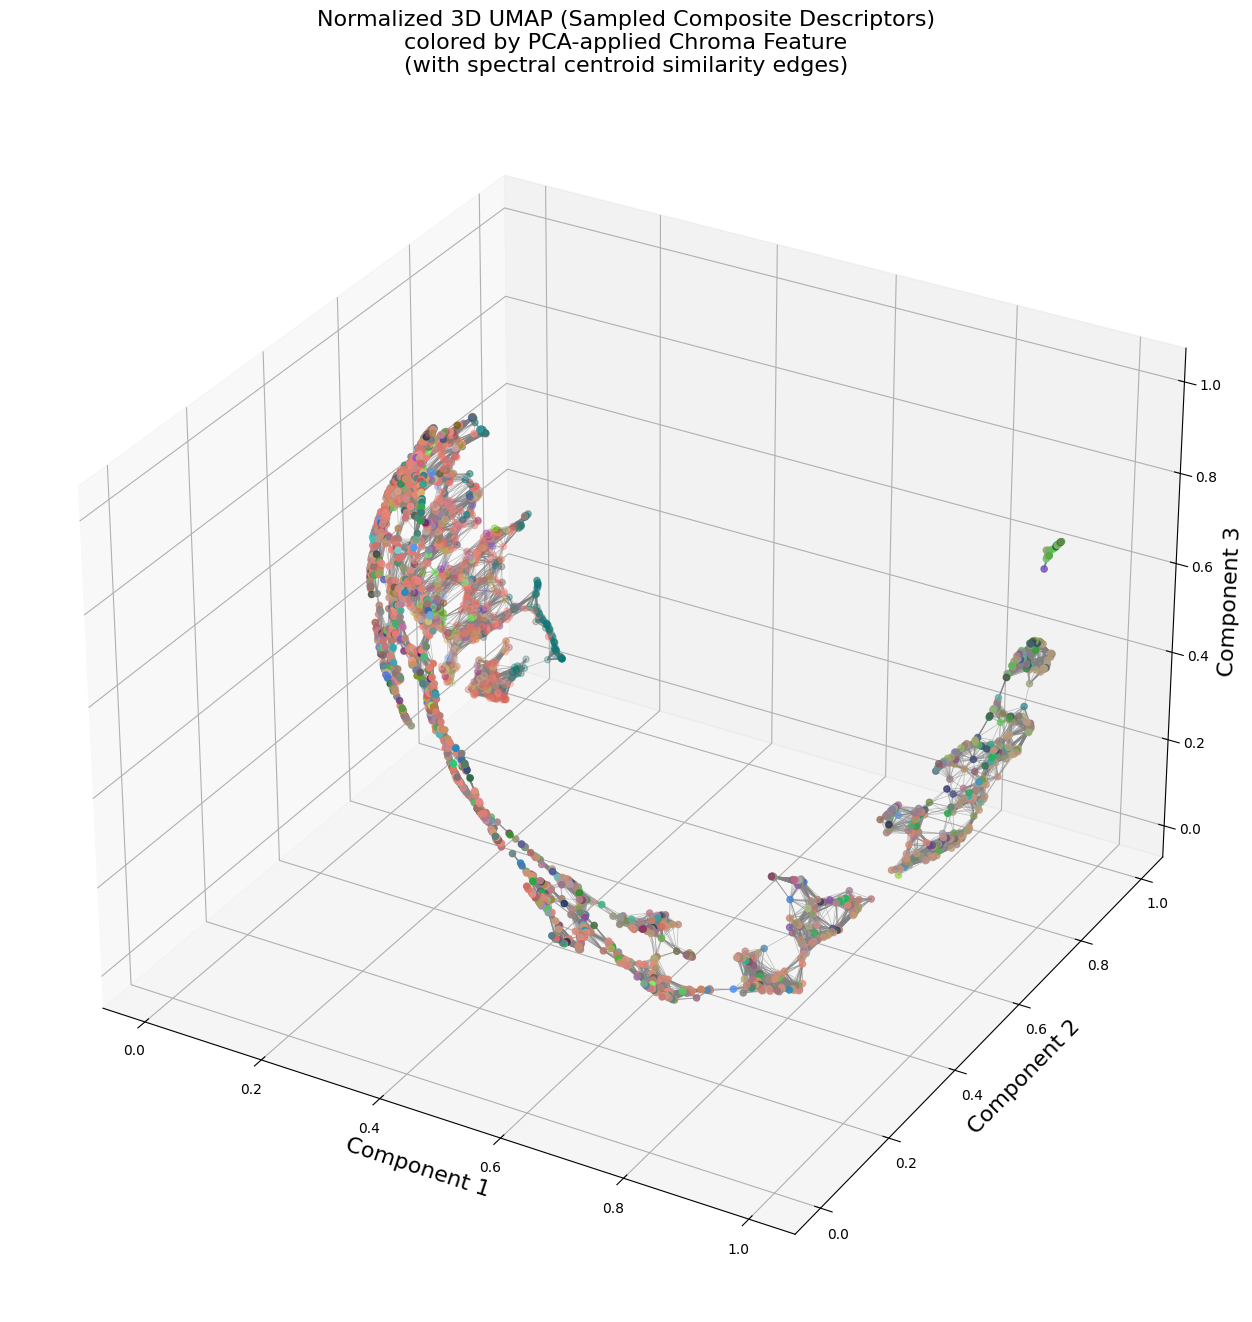

In [ ]:
# 3D scatter plot: UMAP 결과에 PCA-applied 크로마 색상 적용
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
umap_normalized[:, 0],
umap_normalized[:, 1],
umap_normalized[:, 2],
c=chroma_pca_normalized,
marker='o'
)

# 선분 그리기: UMAP 공간상의 거리와 스펙트럴 중심값의 차이가 임계치 이하이면 선분으로 연결
threshold_umap = 0.05   # UMAP embedding 상의 임계치 (normalized 좌표)
threshold_spec = 0.04    # 스펙트럴 중심 정규값 차이 임계치
umap_dists = squareform(pdist(umap_normalized))
spec_diffs = squareform(pdist(spectral_norm.reshape(-1, 1), metric='cityblock'))

pairs = np.where((umap_dists < threshold_umap) & (spec_diffs < threshold_spec))
for i, j in zip(pairs[0], pairs[1]):
    if i < j:
        xs = [umap_normalized[i, 0], umap_normalized[j, 0]]
        ys = [umap_normalized[i, 1], umap_normalized[j, 1]]
        zs = [umap_normalized[i, 2], umap_normalized[j, 2]]
        ax.plot(xs, ys, zs, c='gray', alpha=0.5, linewidth=0.5)

ax.set_title('Normalized 3D UMAP (Sampled Composite Descriptors)\ncolored by PCA-applied Chroma Feature\n(with spectral centroid similarity edges)', fontsize=fontsize)
ax.set_xlabel('Component 1',fontsize=fontsize)
ax.set_ylabel('Component 2',fontsize=fontsize)
ax.set_zlabel('Component 3',fontsize=fontsize)
plt.show()

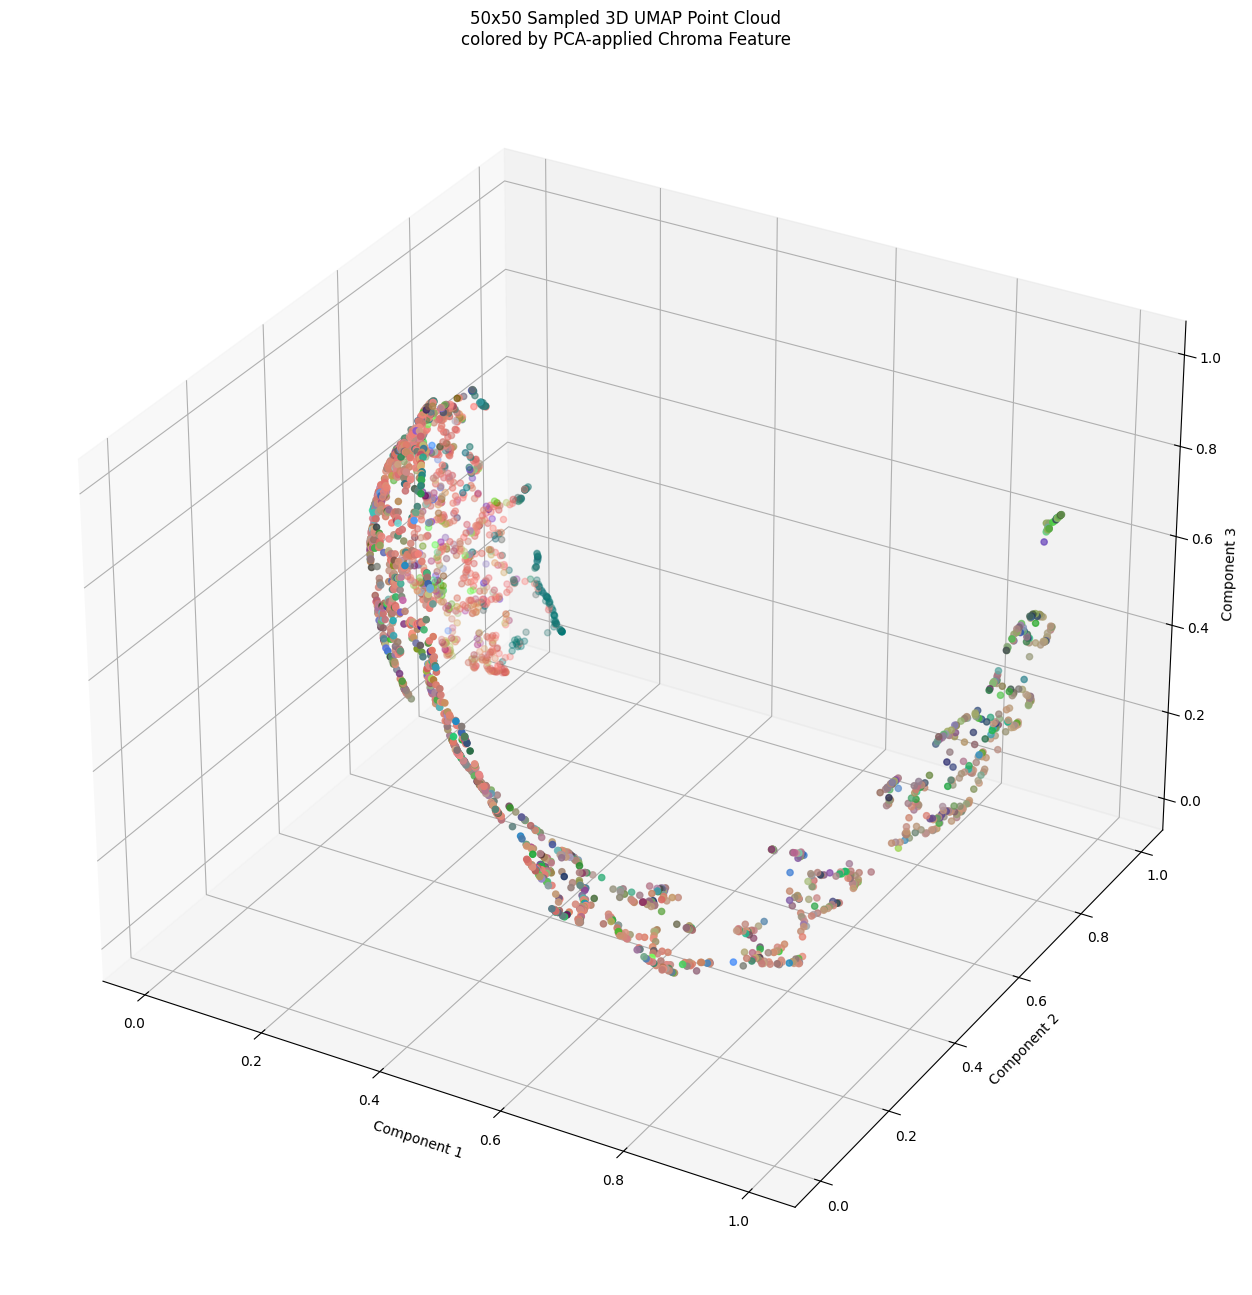

In [ ]:
    
    # ------------------------------------------------------------------------------
    # 기존 UMAP 임베딩 관련 코드 (생략)
    # ------------------------------------------------------------------------------
    # UMAP 임베딩 결과는 umap_normalized에 저장되어 있고, PCA-applied 색상은 chroma_pca_normalized에 저장됨

    # 3D point cloud를 50x50 (총 2500 points)로 샘플링하여 시각화
    grid_rows, grid_cols = 50, 50
    sample_count = grid_rows * grid_cols

    # 샘플링 모드를 선택: 'random' 또는 'block'
    sampling_mode = 'random'  # 또는 'block'

    if sampling_mode == 'random':
        # 무작위 샘플링 (재현을 위해 seed 설정)
        np.random.seed(4)
        if len(umap_normalized) >= sample_count:
            sampled_idx = np.random.choice(len(umap_normalized), sample_count, replace=False)
        else:
            sampled_idx = np.arange(len(umap_normalized))
        umap_sampled = umap_normalized[sampled_idx]
        colors_sampled = chroma_pca_normalized[sampled_idx]
    else:
        # block 샘플링: 사용자가 원하는 시작 인덱스를 지정 (예: 시작 인덱스 0부터 연속적으로 선택)
        start_idx = 0  # 필요에 따라 변경
        end_idx = start_idx + sample_count
        if end_idx <= len(umap_normalized):
            sampled_idx = np.arange(start_idx, end_idx)
        else:
            sampled_idx = np.arange(len(umap_normalized))
        umap_sampled = umap_normalized[sampled_idx]
        colors_sampled = chroma_pca_normalized[sampled_idx]

    # 3D 산점도에 샘플링된 포인트 클라우드 출력 (색상은 PCA-applied chroma 사용)
    fig = plt.figure(figsize=(16, 16))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(
        umap_sampled[:, 0],
        umap_sampled[:, 1],
        umap_sampled[:, 2],
        c=colors_sampled,
        marker='o'
    )
    ax.set_title('50x50 Sampled 3D UMAP Point Cloud\ncolored by PCA-applied Chroma Feature')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.show()


In [ ]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer

# FSD50k.eval.audio.pkl 불러오기
with open('./FSD50k.eval_audio.pkl', 'rb') as f:
    pkl_meta = pickle.load(f)

# 만약 pkl_meta가 dict가 아니라 리스트라면 keys 대신 리스트 자체를 사용
if isinstance(pkl_meta, dict):
    keys = pkl_meta.keys()
elif isinstance(pkl_meta, list):
    keys = pkl_meta
else:
    raise TypeError("pkl_meta 타입이 dict나 list가 아닙니다.")

# eval_clips_info_FSD50K.json 불러오기
with open('./FSD50K.metadata/eval_clips_info_FSD50K.json', 'r') as f:
    json_meta = json.load(f)

# pkl에 저장된 파일 ID와 JSON 메타 데이터의 ID를 매칭하여 태그를 코퍼스로 구성
corpus = []
file_ids = []
for key in keys:
    if key in json_meta:
        tags = json_meta[key].get('tags', [])
        if tags:
            corpus.append(' '.join(tags))
            file_ids.append(key)
    else:
        print(f"키 {key}는 JSON 메타데이터에 없습니다.")

# TF-IDF 벡터화 및 TSNE 2차원 임베딩
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X.toarray())

# tsne 임베딩 결과를 태그 문자열로 시각화
plt.figure(figsize=(12, 8))
for i, text in enumerate(corpus):
    plt.text(X_tsne[i, 0], X_tsne[i, 1], text, fontsize=8)
plt.title("TSNE 기반 FSD50K 태그 코퍼스 시각화")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.show()

TypeError: unhashable type: 'numpy.ndarray'

/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Volumes/Workroom_Studio/python/3d-corpus/research_env/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap

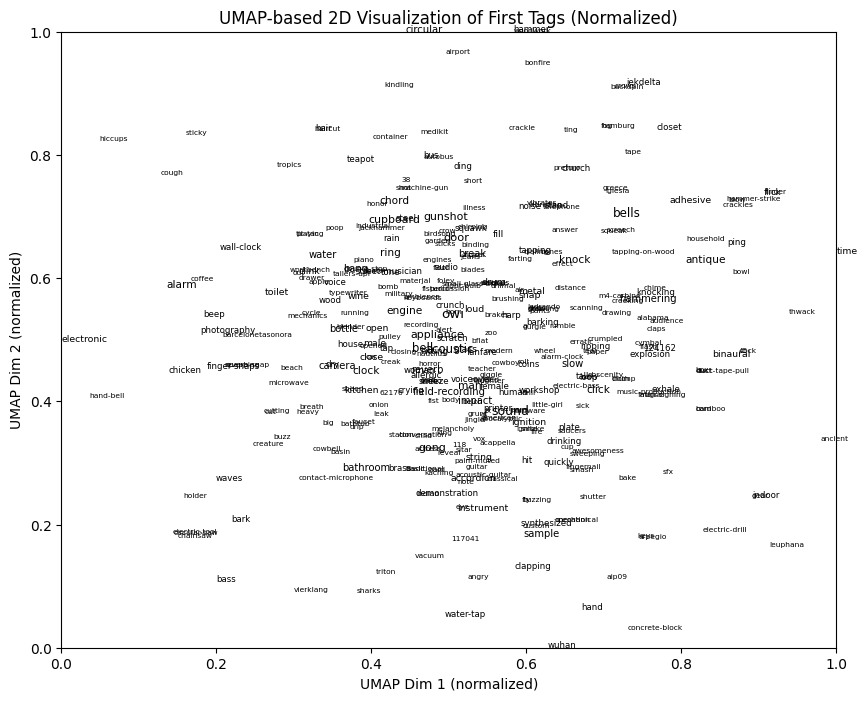

In [ ]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

# pkl 파일 불러오기 (각 요소는 dict: filename, mfccs_mean, spectral_centroid_mean, chroma_mean)
with open('./FSD50k.eval_audio_features.pkl', 'rb') as f:
    pkl_meta = pickle.load(f)

# JSON 메타데이터 불러오기
with open('./FSD50K.metadata/eval_clips_info_FSD50K.json', 'r') as f:
    json_meta = json.load(f)

# corpus 구성: pkl의 filename에서 ID 추출하여 JSON 메타데이터의 태그(들)를 연결
corpus = []
file_ids = []
for feature_data in pkl_meta:
    filename = feature_data.get('filename', '')
    if not filename:
        continue
    # "[ID]_onset_#.wav" 형식에서 ID 추출 (예: "399190")
    audio_id = str(filename).split('_')[0]
    if audio_id in json_meta:
        tags = json_meta[audio_id].get('tags', [])
        if tags:
            corpus.append(' '.join(tags))
            file_ids.append(audio_id)
    else:
        print(f"ID {audio_id} is not found in JSON metadata.")

# TF-IDF 벡터화: corpus를 수치화
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

# UMAP을 이용해 2차원으로 임베딩 (전체 피쳐 공간 축소)
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.3)
X_umap = umap_model.fit_transform(X.toarray())

# 100x100 (총 10,000) 포인트 무작위 샘플링 (메모리 문제 고려)
grid_size = 25
sample_count = grid_size * grid_size
if len(X_umap) >= sample_count:
    sample_inds = np.random.choice(len(X_umap), sample_count, replace=False)
else:
    sample_inds = np.arange(len(X_umap))
X_sample = X_umap[sample_inds]
corpus_sample = [corpus[i] for i in sample_inds]

# 각 데이터 포인트에서 첫 번째 태그만 추출하여 그룹화
first_token_indices = {}
for i, text in enumerate(corpus_sample):
    tokens = text.split()
    if tokens:  # 태그가 있는 경우
        first_token = tokens[0]
        first_token_indices.setdefault(first_token, []).append(i)

# 각 첫 번째 태그별 2차원 평균 좌표 계산
first_tag_coords = {}
for token, indices in first_token_indices.items():
    coords = X_sample[indices]  # 해당 데이터 포인트의 2D 임베딩 좌표
    mean_x = np.mean(coords[:, 0])
    mean_y = np.mean(coords[:, 1])
    first_tag_coords[token] = (mean_x, mean_y)

# 전체 첫 번째 태그 좌표의 중심 계산 후, 태그들을 중심에 더 가깝게 조정 (alpha: 조정 계수)
all_first_coords = np.array(list(first_tag_coords.values()))
center = np.mean(all_first_coords, axis=0)
alpha = 0.1  # 0~1 사이: 1이면 원래 좌표, 작을수록 중심으로 몰림
adjusted_first_coords = {}
for token, (x, y) in first_tag_coords.items():
    new_x = center[0] + alpha * (x - center[0])
    new_y = center[1] + alpha * (y - center[1])
    adjusted_first_coords[token] = (new_x, new_y)

# 조정된 좌표를 0~1 사이로 노멀라이제이션
all_adjusted = np.array(list(adjusted_first_coords.values()))
min_xy = np.min(all_adjusted, axis=0)
max_xy = np.max(all_adjusted, axis=0)
normalized_first_coords = {}
for token, (x, y) in adjusted_first_coords.items():
    norm_x = (x - min_xy[0]) / (max_xy[0] - min_xy[0])
    norm_y = (y - min_xy[1]) / (max_xy[1] - min_xy[1])
    normalized_first_coords[token] = (norm_x, norm_y)

# 각 태그의 등장 빈도(데이터 포인트 수)를 계산 (폰트 크기 조정을 위해)
first_token_counter = {token: len(indices) for token, indices in first_token_indices.items()}

# 모든 첫 번째 태그를 2D 공간에 시각화 (영문 타이틀)
plt.figure(figsize=(10, 8), dpi=100)
for token, (x, y) in normalized_first_coords.items():
    frequency = first_token_counter[token]
    fontsize = 4 + 2 * np.log(frequency + 1)  # 빈도에 따라 폰트 크기 조정
    plt.text(x, y, token, fontsize=fontsize)
plt.title("UMAP-based 2D Visualization of First Tags (Normalized)")
plt.xlabel("UMAP Dim 1 (normalized)")
plt.ylabel("UMAP Dim 2 (normalized)")
plt.show()